In [1]:
import numpy as np
np.NAN = np.nan
import torch
from deepod.models.time_series import COUTA
from utils.data_loader import load_volvo, load_optuna_val
from utils.evaluation import evaluate_model, cross_validate
from utils.hyperparameter_search import run_optuna_study
result_path = "../Results/Volvo COUTA"

C:\Users\louis\PycharmProjects\Exjobb-Gitrepo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, y_train, X_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/volvoTrain.csv",
    "../Dataset/volvoTest.csv"
)

In [3]:
hyperparameters = {
    "lr": ("categorical", [1e-5, 1e-4, 1e-3]),
    "rep_dim": ("int", 8, 32, False),
    "epochs": ("int", 20, 80, False),
}

df_train_optuna = load_optuna_val(df_train)

study = run_optuna_study(
    model_class=COUTA,
    hyperparameters=hyperparameters,
    train_df=df_train_optuna,
    validation_ratio=0.2,
    n_trials=10,
    study_name="couta_optuna_actual_study",
    storage="sqlite:///couta_optuna_actual.db"
)

print("Best params:", study.best_params)
print("Best validation score:", study.best_value)
print("Best trial extra metrics:", study.best_trial.user_attrs)

Best params: {'lr': 0.0001, 'rep_dim': 30, 'epochs': 35}
Best validation score: 0.2827146058182611
Best trial extra metrics: {'pr_auc': 0.2827146058182611}


In [4]:
best_params = study.best_params
static_params = {
    "seq_len": 50,
    "stride": 5,
    "train_val_pc": 0
}

params = best_params | static_params
cross_val_scores = cross_validate(train_df=df_train, model=COUTA, params=params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.5740733846656739, 'fold1_pr_auc': 0.02413697449942688, 'fold2_roc_auc': 0.858816974856734, 'fold2_pr_auc': 0.11648189742210628, 'mean_threshold': np.float64(0.13189364954087068)}


In [5]:
model = COUTA(**params)

model.fit(X_train)

scores = model.decision_function(X_test)

|>>> epoch: 35  |   loss: 0.015124, loss_oc: 0.002720, val_loss: nan


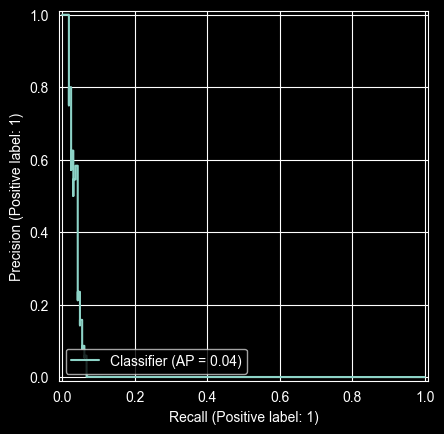

In [6]:
results = evaluate_model(y_test, scores, threshold=cross_val_scores["mean_threshold"], result_path=result_path)
print(results)

In [7]:
import pandas as pd
import os
df = pd.DataFrame(scores, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index=False)